### Installing the YOLO Framework

In [4]:
!pip install ultralytics -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 75.1 MB/s eta 0:00:00


In [5]:
import os
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [1]:
!unzip -q banana_dataset.zip -d dataset/

In [7]:
base_dir = '/content/dataset'
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'valid')

# YOLOv8 CLASSIFICATION (Ripeness Grading)

In [6]:
# Load the YOLOv8 nano classification model
model_cls = YOLO('yolov8n-cls.pt')

### Training the model

In [8]:
print("Starting YOLO Classification Training...")
results_cls = model_cls.train(
    data=base_dir,
    epochs=10,             # 10 epochs is usually sufficient for YOLO fine-tuning
    imgsz=416,             # Using the 416x416 size specified in the project
    project='yolo_models', # Folder where results will be saved
    name='banana_cls'      # Subfolder for this specific run
)

Starting YOLO Classification Training...
Ultralytics 8.4.78 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset, degrees=0.0, deterministic=True, device=None, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=banana_cls, nbs=64, nms=False, opset=None

In [10]:
yolo_cls_path = '/content/yolo_models/banana_cls/weights/best.pt'

# YOLOv8 DETECTION AND COUNTING

In [15]:
print("\n--- YOLOv8 Object Detection and Counting ---")

# 1. Load the pre-trained YOLOv8 nano detection model

model_det = YOLO('yolov8n.pt')

# 2. Saving a copy of this pre-trained model to match required project deliverables
model_det.save('yolo_detect_best.pt')
print("Detection model saved as 'yolo_detect_best.pt'")

# 3. Creating a function to detect, count, and visualize bananas
def detect_and_count_bananas(image_path):
    """
    Takes an image path, uses YOLOv8 to detect bananas (COCO Class 46),
    draws bounding boxes, and prints the total count.
    """
    # Run inference. 'classes=[46]' forces the model to ONLY look for bananas.
    results = model_det.predict(source=image_path, classes=[46], conf=0.25)

    # Extract the result object
    result = results[0]

    # The number of boxes detected equals the number of bananas
    banana_count = len(result.boxes)

    # Plot the results (draws the bounding boxes on the image)
    annotated_img = result.plot()

    # Convert BGR (OpenCV format) to RGB (Matplotlib format) for correct colors
    annotated_img_rgb = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)

    # Display the image and the count
    plt.figure(figsize=(8, 8))
    plt.imshow(annotated_img_rgb)
    plt.axis('off')
    plt.title(f"Bananas Detected: {banana_count}", fontsize=16, fontweight='bold', color='green')
    plt.show()

    return banana_count


--- YOLOv8 Object Detection and Counting ---
Detection model saved as 'yolo_detect_best.pt'


# Testing the Counter

Testing on image: musa-acuminata-ripe-92b6c27e-1d0a-11ec-a04b-d8c4975e38aa_jpg.rf.d8030a9ea38c9123f4e67996d1541976.jpg

image 1/1 /content/dataset/test/ripe/musa-acuminata-ripe-92b6c27e-1d0a-11ec-a04b-d8c4975e38aa_jpg.rf.d8030a9ea38c9123f4e67996d1541976.jpg: 640x640 1 banana, 8.3ms
Speed: 4.2ms preprocess, 8.3ms inference, 3.1ms postprocess per image at shape (1, 3, 640, 640)


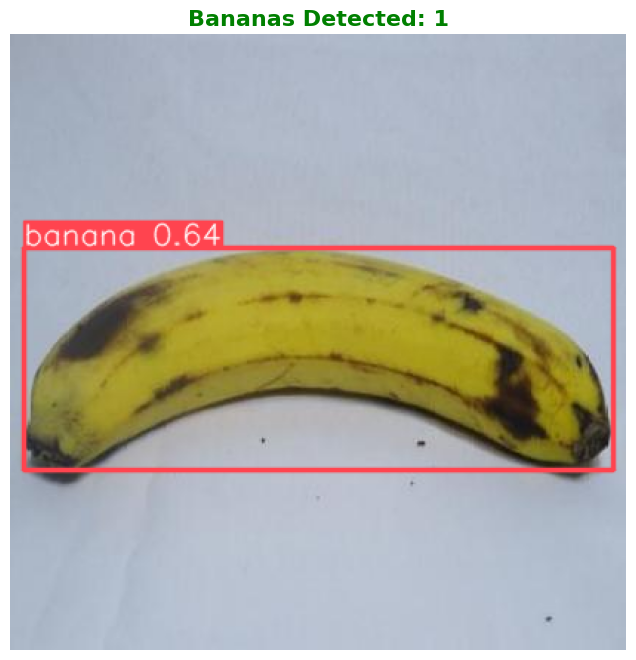

Final Count for this image: 1


In [16]:
# Let's grab a random image from your test set to see it in action
# Adjust this path if you want to test a specific image!
test_image_folder = os.path.join(base_dir, 'test/ripe')
sample_images = os.listdir(test_image_folder)

if len(sample_images) > 0:
    sample_image_path = os.path.join(test_image_folder, sample_images[0])
    print(f"Testing on image: {sample_images[0]}")

    # Run our function!
    count = detect_and_count_bananas(sample_image_path)
    print(f"Final Count for this image: {count}")
else:
    print("Could not find a test image in the specified directory.")